## PINNs: An Example of a 1D ODE Solver

This notebook introduces the core idea of physics-informed neural networks (PINNs) through a simple ODE example. A foundational reference is the 2019 PINNs paper ([RPK19](./RPK19_PINNs.pdf)), which presents a framework for solving forward and inverse problems by embedding nonlinear partial differential equations (PDEs) into a neural network loss function.

__1D ODE__

Consider the 1D linear ODE
$$
u'(x) + u(x) = 0,\quad u(0)=1.
$$
Its exact solution is
$$
u(x)=e^{-x}.
$$

We use **physics-informed neural networks (PINNs)** to approximate this solution on the interval $[0,1]$.

Rewrite the ODE as
$$
F(u(x),u'(x))=0,\quad u(0)=1,
$$
with
$$
F(a,b)=a+b.
$$

A function $u$ solves the problem if and only if
$$
G(u,u',u(0))=\|F(u,u')\|_2 + |u(0)-1|=0.
$$

To implement this idea, define a neural-network hypothesis class
$$
\mathcal{N}=\{h_\theta:\theta\in\mathbb{R}^m\},
$$
and determine $\theta^*$ by minimizing
$$
\theta^*=\arg\min_\theta\, G\!\left(h_\theta,h'_\theta,h_\theta(0)\right).
$$

Then $h_{\theta^*}$ serves as the PINN approximation of $u$.

Epoch    0 | Loss: 1.029083e+00
Epoch  500 | Loss: 1.030398e-04
Epoch 1000 | Loss: 1.937079e-05
Epoch 1500 | Loss: 1.356251e-05
Epoch 2000 | Loss: 9.323965e-06
Epoch 2500 | Loss: 5.817774e-06
Epoch 3000 | Loss: 3.223615e-06
Epoch 3500 | Loss: 2.463534e-04
Epoch 4000 | Loss: 7.568188e-07
Epoch 4500 | Loss: 3.105873e-07


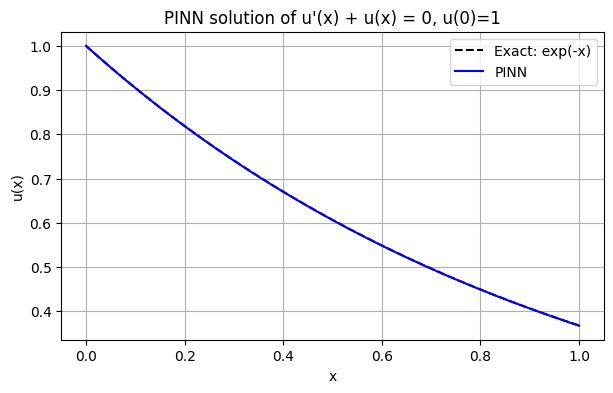

In [1]:
import torch

import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

# PINN model
class PINN(nn.Module):
    def __init__(self, hidden=32, depth=3):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = PINN(hidden=32, depth=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Collocation points in [0, 1]
x_f = torch.linspace(0, 1, 200).view(-1, 1)
x_f.requires_grad_(True)

# Boundary point x=0 with u(0)=1
x0 = torch.tensor([[0.0]])

# Training
epochs = 5000
for epoch in range(epochs):
    optimizer.zero_grad()

    u = model(x_f)
    du_dx = torch.autograd.grad(
        u, x_f, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]

    # ODE residual: u' + u = 0
    f = du_dx + u
    loss_pde = torch.mean(f**2)

    # Boundary condition: u(0)=1
    u0 = model(x0)
    loss_bc = (u0 - 1.0).pow(2).mean()

    loss = loss_pde + loss_bc
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6e}")

# Evaluation
x_test = torch.linspace(0, 1, 200).view(-1, 1)
with torch.no_grad():
    u_pred = model(x_test).squeeze().numpy()

u_exact = torch.exp(-x_test).squeeze().numpy()
x_np = x_test.squeeze().numpy()

# Plot
plt.figure(figsize=(7, 4))
plt.plot(x_np, u_exact, "k--", label="Exact: exp(-x)")
plt.plot(x_np, u_pred, "b", label="PINN")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("PINN solution of u'(x) + u(x) = 0, u(0)=1")
plt.legend()
plt.grid(True)
plt.show()